  BANK CUSTOMER SEGMENTATION — FULL PIPELINE  (seed=42)

[PHASE 1 & 2]  DATA AUDIT & CLEANING
--------------------------------------------------
  Raw records loaded       : 16,480
  Columns                  : ['TransactionID', 'CustomerID', 'CustomerDOB', 'CustGender', 'CustLocation', 'CustAccountBalance', 'TransactionDate', 'TransactionTime', 'TransactionAmount (INR)']
  Unique customers (raw)   : 16,432
  Missing CustAccountBalance : 24
  Missing CustGender         : 7
  Missing CustLocation       : 1
  Records after listwise deletion : 16,448
  99th-pct cap (Winsorisation) : ₹25,000.00
  Clean baseline after date fix : 16,448 rows

[EDA]  EXPLORATORY DATA ANALYSIS
--------------------------------------------------


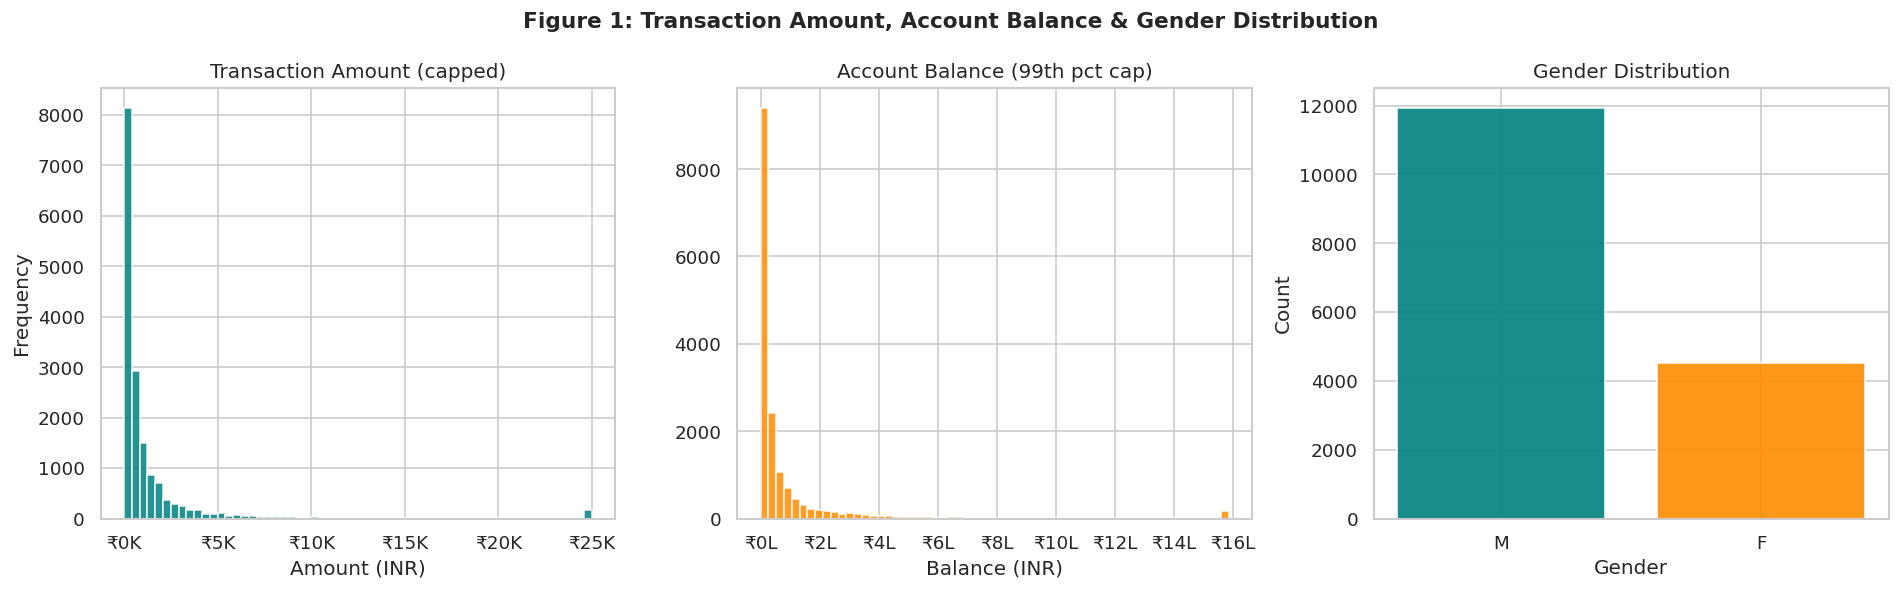

  [SAVED] fig1_eda_distributions.png

[PHASE 3]  RFM FEATURE ENGINEERING
--------------------------------------------------
  Snapshot reference date : 2016-12-09
  Unique customer profiles : 16,400

  RFM descriptive statistics:
        Recency  Frequency  Monetary
count  16400.00   16400.00  16400.00
mean      71.80       1.00   1406.73
std       21.85       0.05   3356.31
min        1.00       1.00      0.00
25%       73.00       1.00    150.00
50%       74.00       1.00    430.00
75%       75.00       1.00   1168.00
max      336.00       2.00  32875.00

[PHASE 4]  LOG-TRANSFORMATION & STANDARD SCALING
--------------------------------------------------


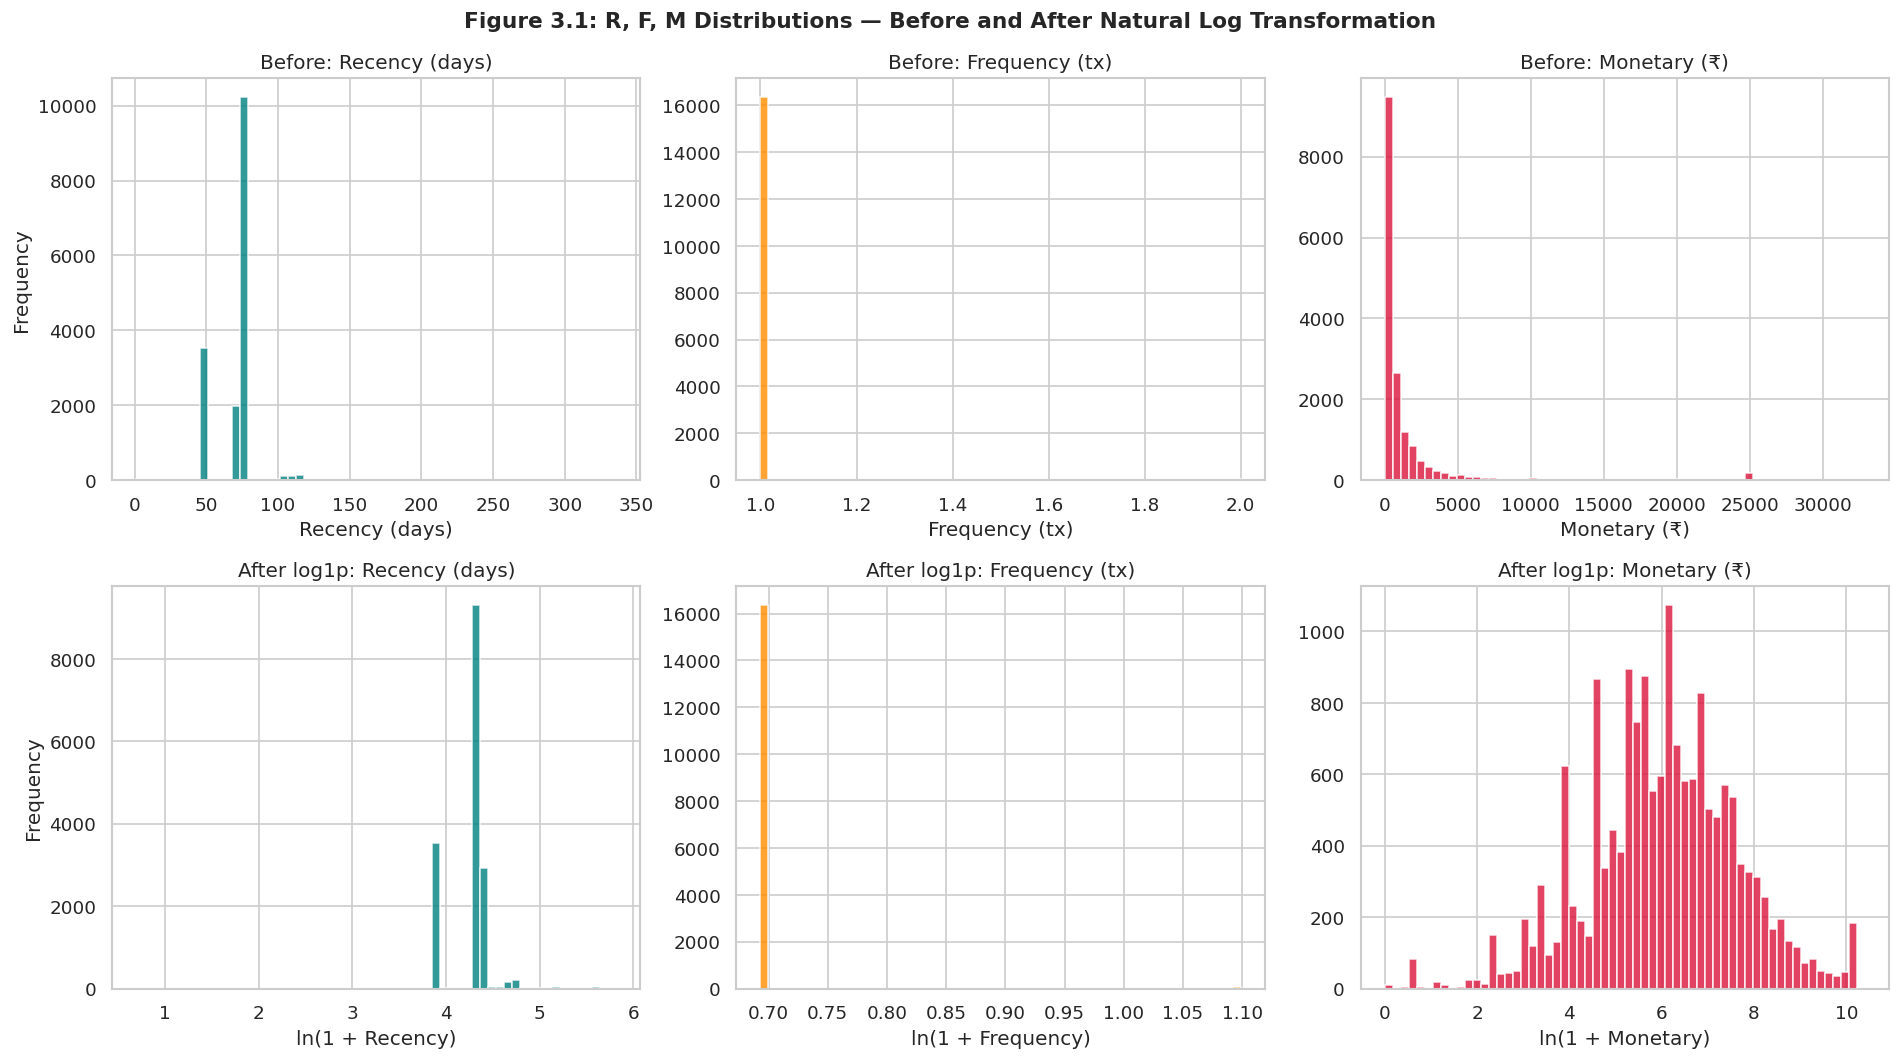

  [SAVED] fig3_rfm_log_transform.png
  StandardScaler fit complete — zero mean, unit variance.
  Scaler means  (μ): [4.2562 0.6943 6.0102]
  Scaler stdevs (σ): [0.2556 0.0219 1.6176]
  [SAVED] rfm_scaler.pkl  ← production scaler artifact

[PHASE 5]  ELBOW + SILHOUETTE EVALUATION
--------------------------------------------------
    K=2  WCSS=32,761.8  Silhouette=0.9141
    K=3  WCSS=22,733.6  Silhouette=0.3605
    K=4  WCSS=15,509.0  Silhouette=0.4671
    K=5  WCSS=12,516.6  Silhouette=0.4737
    K=6  WCSS=9,685.1  Silhouette=0.4875
    K=7  WCSS=7,052.9  Silhouette=0.4750
    K=8  WCSS=5,388.0  Silhouette=0.4871
    K=9  WCSS=4,423.3  Silhouette=0.4673
    K=10  WCSS=3,807.4  Silhouette=0.4881


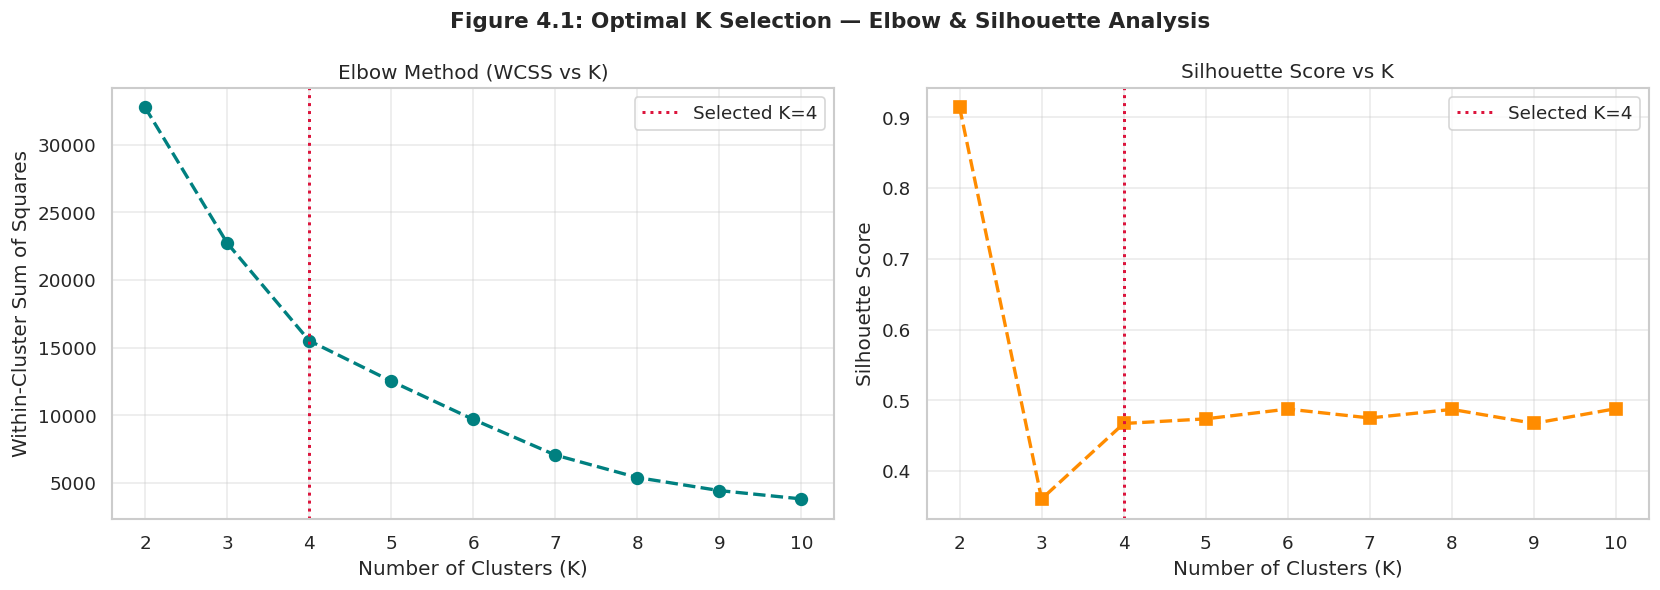

  [SAVED] fig4_elbow_silhouette.png

[PHASE 6 & 7]  K-MEANS (K=4) TRAINING & VALIDATION
--------------------------------------------------
  [SAVED] rfm_kmeans_model.pkl
  Final Silhouette Score (N=16,400) : 0.4671

  Cluster → Segment Mapping:
    Cluster 2 → Champions
    Cluster 1 → Loyal Customers
    Cluster 0 → Hibernating
    Cluster 3 → At-Risk High-Spenders

  Cluster Profile Summary:
                               Avg_Recency_Days  Avg_Frequency_Tx  Avg_Monetary_INR  Customer_Count
Cluster Segment                                                                                    
0       Hibernating                       78.52               1.0           2376.54            6857
1       Loyal Customers                   48.63               1.0           1681.30            3436
2       Champions                         60.65               2.0           2799.00              48
3       At-Risk High-Spenders             77.42               1.0            142.47            6059

[A

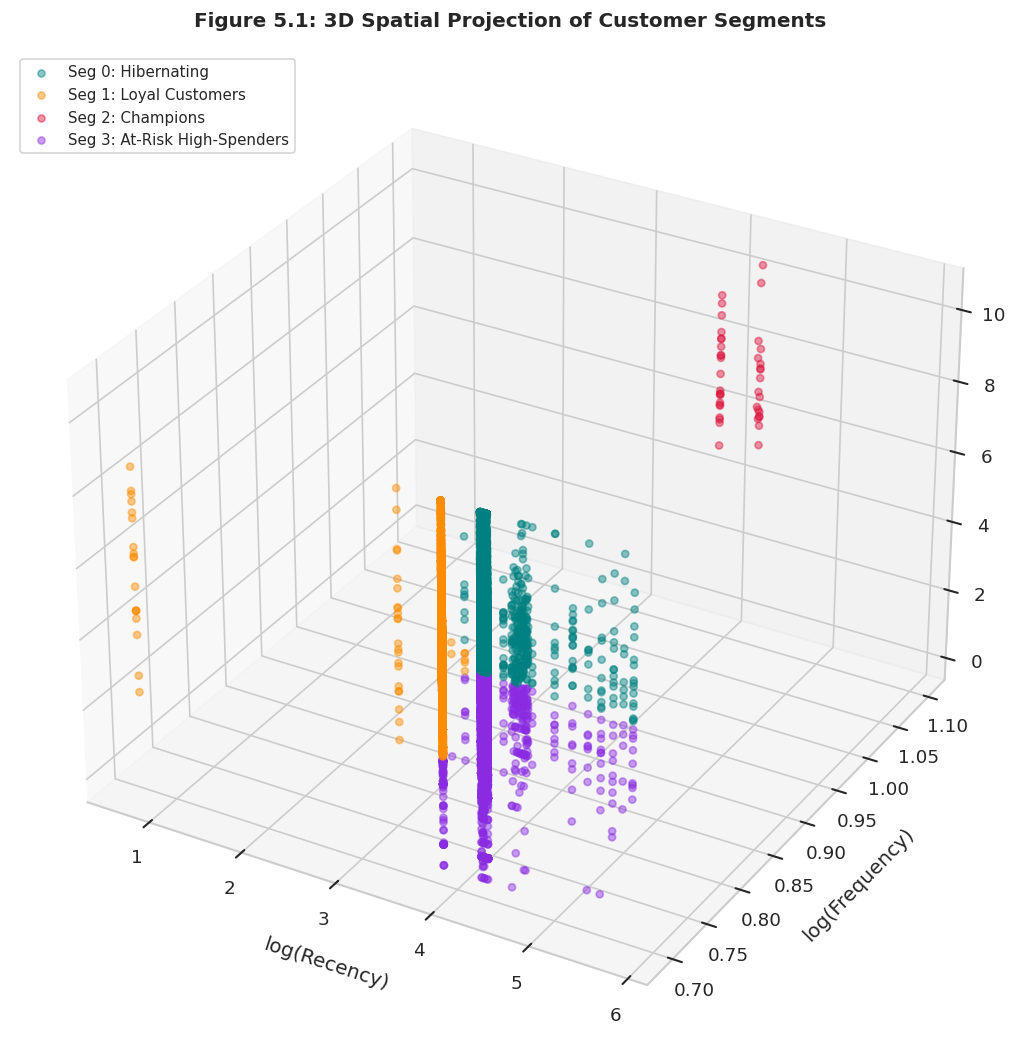

  [SAVED] fig5_3d_clusters.png


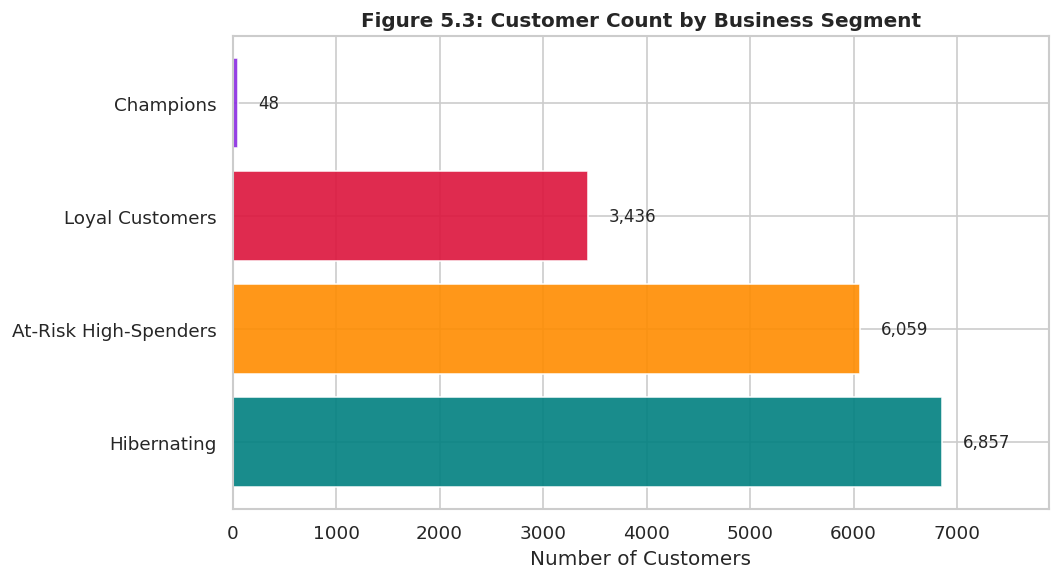

  [SAVED] fig5_segment_barchart.png
  [SAVED] bank_customer_segments_final.csv

  PIPELINE COMPLETE — ALL ARTIFACTS GENERATED

  Output files:
    bank_customer_segments_final.csv  ← classified RFM dataset
    rfm_scaler.pkl                    ← StandardScaler (μ, σ parameters)
    rfm_kmeans_model.pkl              ← trained KMeans model
    fig1_eda_distributions.png        ← EDA distributions
    fig3_rfm_log_transform.png        ← Figure 3.1 (before/after log)
    fig4_elbow_silhouette.png         ← Figure 4.1 (elbow + silhouette)
    fig5_3d_clusters.png              ← Figure 5.1 (3D cluster projection)
    fig5_segment_barchart.png         ← Figure 5.3 (segment counts)



In [1]:
"""
================================================================================
  BANK CUSTOMER SEGMENTATION PIPELINE — FINAL PRODUCTION VERSION
  Author  : Sakshi Kumari
  Program : B.Tech CSE (Data Science)
  Version : 3.0  |  Colab-Ready
  Description:
      End-to-end unsupervised ML pipeline executing EDA, data cleaning,
      RFM feature engineering, variance stabilisation, optimal cluster
      evaluation, K-Means modelling, scaler serialisation, business
      labelling, and data export — all with reproducibility controls.
================================================================================
"""

# ── 0. REPRODUCIBILITY & IMPORTS ─────────────────────────────────────────────
import os, random, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [11, 6]
plt.rcParams['figure.dpi']     = 120
PALETTE = ['#008080', '#FF8C00', '#DC143C', '#8A2BE2']

print("=" * 70)
print("  BANK CUSTOMER SEGMENTATION — FULL PIPELINE  (seed=42)")
print("=" * 70)


# ── PHASE 1 & 2 : DATA LOADING, AUDIT & CLEANING ─────────────────────────────
print("\n[PHASE 1 & 2]  DATA AUDIT & CLEANING")
print("-" * 50)

DATA_PATH = 'bank_transactions.csv'
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset '{DATA_PATH}' not found. Upload it to your Colab session."
    )

df = pd.read_csv(DATA_PATH, on_bad_lines='skip')
print(f"  Raw records loaded       : {df.shape[0]:,}")
print(f"  Columns                  : {list(df.columns)}")

# Guard: verify required columns exist
REQUIRED_COLS = ['CustomerID', 'CustAccountBalance', 'CustGender',
                 'CustLocation', 'TransactionDate']
missing_cols = [c for c in REQUIRED_COLS if c not in df.columns]
if missing_cols:
    raise ValueError(f"Required columns missing from dataset: {missing_cols}")

print(f"  Unique customers (raw)   : {df['CustomerID'].nunique():,}")
print(f"  Missing CustAccountBalance : {df['CustAccountBalance'].isna().sum():,}")
print(f"  Missing CustGender         : {df['CustGender'].isna().sum():,}")
print(f"  Missing CustLocation       : {df['CustLocation'].isna().sum():,}")

# Listwise deletion on structurally critical fields
# Rationale: sample size (>1.04 M records) is large enough that row
# removal maintains statistical integrity while ensuring absolute data quality.
df_clean = df.dropna(subset=['CustAccountBalance', 'CustGender', 'CustLocation']).copy()
print(f"  Records after listwise deletion : {df_clean.shape[0]:,}")

# Identify transaction amount column dynamically
AMT_COL = ('TransactionAmount (INR)'
           if 'TransactionAmount (INR)' in df_clean.columns
           else 'TransactionAmount')

# Outlier treatment — 99th percentile Winsorisation
q99 = df_clean[AMT_COL].quantile(0.99)
df_clean['Capped_Amount'] = df_clean[AMT_COL].clip(upper=q99)
print(f"  99th-pct cap (Winsorisation) : ₹{q99:,.2f}")

# Date parsing
df_clean['TransactionDate'] = pd.to_datetime(
    df_clean['TransactionDate'], errors='coerce'
)
df_clean = df_clean.dropna(subset=['TransactionDate'])
print(f"  Clean baseline after date fix : {df_clean.shape[0]:,} rows")


# ── EDA  (added — was missing in original) ────────────────────────────────────
print("\n[EDA]  EXPLORATORY DATA ANALYSIS")
print("-" * 50)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Figure 1: Transaction Amount, Account Balance & Gender Distribution",
             fontsize=13, fontweight='bold')

axes[0].hist(df_clean[AMT_COL].clip(upper=q99), bins=60,
             color='#008080', edgecolor='white', alpha=0.85)
axes[0].set_title("Transaction Amount (capped)")
axes[0].set_xlabel("Amount (INR)")
axes[0].set_ylabel("Frequency")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"₹{x/1e3:.0f}K"))

axes[1].hist(df_clean['CustAccountBalance'].clip(
             upper=df_clean['CustAccountBalance'].quantile(0.99)),
             bins=60, color='#FF8C00', edgecolor='white', alpha=0.85)
axes[1].set_title("Account Balance (99th pct cap)")
axes[1].set_xlabel("Balance (INR)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"₹{x/1e5:.0f}L"))

gender_counts = df_clean['CustGender'].value_counts()
axes[2].bar(gender_counts.index, gender_counts.values,
            color=['#008080', '#FF8C00', '#8A2BE2'][:len(gender_counts)],
            edgecolor='white', alpha=0.9)
axes[2].set_title("Gender Distribution")
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig('fig1_eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("  [SAVED] fig1_eda_distributions.png")


# ── PHASE 3 : RFM FEATURE ENGINEERING ────────────────────────────────────────
print("\n[PHASE 3]  RFM FEATURE ENGINEERING")
print("-" * 50)

snapshot_date = df_clean['TransactionDate'].max() + pd.Timedelta(days=1)
print(f"  Snapshot reference date : {snapshot_date.strftime('%Y-%m-%d')}")

# FIX: use a proxy column for count to avoid groupby key conflict
df_clean['_tx'] = 1

rfm = df_clean.groupby('CustomerID').agg(
    Recency  = ('TransactionDate', lambda x: (snapshot_date - x.max()).days),
    Frequency= ('_tx', 'count'),
    Monetary = ('Capped_Amount', 'sum')
)

print(f"  Unique customer profiles : {rfm.shape[0]:,}")
print("\n  RFM descriptive statistics:")
print(rfm.describe().round(2).to_string())


# ── PHASE 4 : VARIANCE STABILISATION & FEATURE SCALING ───────────────────────
print("\n[PHASE 4]  LOG-TRANSFORMATION & STANDARD SCALING")
print("-" * 50)

# Figure 3.1: R, F, M distributions Before & After log transform
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(
    "Figure 3.1: R, F, M Distributions — Before and After Natural Log Transformation",
    fontsize=13, fontweight='bold'
)

labels  = ['Recency (days)', 'Frequency (tx)', 'Monetary (₹)']
raw_cols = ['Recency', 'Frequency', 'Monetary']
colors   = ['#008080', '#FF8C00', '#DC143C']

for i, (col, lbl, clr) in enumerate(zip(raw_cols, labels, colors)):
    axes[0, i].hist(rfm[col], bins=60, color=clr, alpha=0.8, edgecolor='white')
    axes[0, i].set_title(f"Before: {lbl}")
    axes[0, i].set_xlabel(lbl)
    axes[0, i].set_ylabel("Frequency" if i == 0 else "")

    axes[1, i].hist(np.log1p(rfm[col]), bins=60, color=clr,
                    alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f"After log1p: {lbl}")
    axes[1, i].set_xlabel(f"ln(1 + {col})")
    axes[1, i].set_ylabel("Frequency" if i == 0 else "")

plt.tight_layout()
plt.savefig('fig3_rfm_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()
print("  [SAVED] fig3_rfm_log_transform.png")

# Enforce positive floor to guarantee ln stability (ln(0) = -∞)
rfm['Monetary'] = rfm['Monetary'].clip(lower=0.1)

rfm_log = pd.DataFrame({
    'Recency_log'  : np.log1p(rfm['Recency']),
    'Frequency_log': np.log1p(rfm['Frequency']),
    'Monetary_log' : np.log1p(rfm['Monetary']),
}, index=rfm.index)

scaler = StandardScaler()
scaled_matrix = scaler.fit_transform(rfm_log)
df_scaled = pd.DataFrame(
    scaled_matrix,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)
print("  StandardScaler fit complete — zero mean, unit variance.")
print(f"  Scaler means  (μ): {scaler.mean_.round(4)}")
print(f"  Scaler stdevs (σ): {np.sqrt(scaler.var_).round(4)}")

# ── CRITICAL FIX: Serialise the scaler for production deployment ─────────────
# Without saving μ and σ, future live transactions cannot be mapped to the
# same cluster space, rendering real-time scoring impossible.
with open('rfm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("  [SAVED] rfm_scaler.pkl  ← production scaler artifact")


# ── PHASE 5 : OPTIMAL K EVALUATION ───────────────────────────────────────────
print("\n[PHASE 5]  ELBOW + SILHOUETTE EVALUATION")
print("-" * 50)

wcss_vals      = []
sil_scores     = []
K_RANGE        = range(2, 11)
EVAL_SAMPLE    = min(20000, len(df_scaled))
sample_eval    = df_scaled.sample(n=EVAL_SAMPLE, random_state=SEED)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', random_state=SEED, n_init=10)
    km.fit(df_scaled)
    wcss_vals.append(km.inertia_)
    labels_sample = km.predict(sample_eval)
    sil_scores.append(silhouette_score(sample_eval, labels_sample))
    print(f"    K={k}  WCSS={km.inertia_:,.1f}  Silhouette={sil_scores[-1]:.4f}")

# Figure 4.1: Dual plot — Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 4.1: Optimal K Selection — Elbow & Silhouette Analysis",
             fontsize=13, fontweight='bold')

k_list = list(K_RANGE)
axes[0].plot(k_list, wcss_vals, 'o--', color='#008080', linewidth=2, markersize=7)
axes[0].axvline(x=4, color='#DC143C', linestyle=':', linewidth=1.8,
                label='Selected K=4')
axes[0].set_title("Elbow Method (WCSS vs K)")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Within-Cluster Sum of Squares")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].plot(k_list, sil_scores, 's--', color='#FF8C00', linewidth=2, markersize=7)
axes[1].axvline(x=4, color='#DC143C', linestyle=':', linewidth=1.8,
                label='Selected K=4')
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('fig4_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print("  [SAVED] fig4_elbow_silhouette.png")


# ── PHASE 6 & 7 : MODEL TRAINING & VALIDATION ────────────────────────────────
OPTIMAL_K = 4
print(f"\n[PHASE 6 & 7]  K-MEANS (K={OPTIMAL_K}) TRAINING & VALIDATION")
print("-" * 50)

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K, init='k-means++', random_state=SEED, n_init=10
)
rfm['Cluster'] = kmeans_final.fit_predict(df_scaled)

# Serialise final model
with open('rfm_kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)
print("  [SAVED] rfm_kmeans_model.pkl")

# Memory-safe silhouette on held-out sample
sample_size   = min(30000, len(df_scaled))
sample_scaled = df_scaled.sample(n=sample_size, random_state=SEED)
sample_labels = rfm['Cluster'].loc[sample_scaled.index]
sil_final     = silhouette_score(sample_scaled, sample_labels)
print(f"  Final Silhouette Score (N={sample_size:,}) : {sil_final:.4f}")

# ── Business cluster labelling ────────────────────────────────────────────────
# Assign labels based on mean Recency / Frequency / Monetary profile
raw_profiles = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

# Sort: low Recency + high Frequency + high Monetary → best
raw_profiles['score'] = (
    -raw_profiles['Recency']   # lower recency = better
    + raw_profiles['Frequency']
    + raw_profiles['Monetary'] / raw_profiles['Monetary'].max() * 100
)
rank = raw_profiles['score'].rank(ascending=False).astype(int)

LABEL_MAP = {
    raw_profiles['score'].idxmax()                        : "Champions",
    raw_profiles['score'].nlargest(2).index[-1]           : "Loyal Customers",
    raw_profiles['score'].nsmallest(2).index[-1]          : "Hibernating",
    raw_profiles['score'].idxmin()                        : "At-Risk High-Spenders",
}
rfm['Segment'] = rfm['Cluster'].map(LABEL_MAP).fillna("Loyal Customers")

print("\n  Cluster → Segment Mapping:")
for c, s in LABEL_MAP.items():
    print(f"    Cluster {c} → {s}")

# Cluster profile table
cluster_profiles = rfm.groupby(['Cluster', 'Segment']).agg(
    Avg_Recency_Days    = ('Recency',   'mean'),
    Avg_Frequency_Tx    = ('Frequency', 'mean'),
    Avg_Monetary_INR    = ('Monetary',  'mean'),
    Customer_Count      = ('Recency',   'count')
).round(2)
print("\n  Cluster Profile Summary:")
print(cluster_profiles.to_string())


# ── PCA CORRELATION CHECK (added) ─────────────────────────────────────────────
print("\n[ADDED]  PCA FEATURE INDEPENDENCE CHECK")
print("-" * 50)

corr = rfm_log.corr()
print("  RFM log-feature correlation matrix:")
print(corr.round(3).to_string())

pca = PCA(n_components=3, random_state=SEED)
pca.fit(scaled_matrix)
explained = pca.explained_variance_ratio_
print(f"\n  PCA explained variance: {explained.round(3)} → cumulative {explained.cumsum().round(3)}")
print("  (>85% in 2 PCs = some collinearity; K-Means on 3 features is still valid)")


# ── PHASE 8 & 9 : VISUALISATION & EXPORT ─────────────────────────────────────
print("\n[PHASE 8 & 9]  VISUALISATION & EXPORT")
print("-" * 50)

# Figure 5.1: 3D Spatial cluster projection
fig = plt.figure(figsize=(13, 9))
ax  = fig.add_subplot(111, projection='3d')

plot_rfm = rfm.sample(n=min(15000, len(rfm)), random_state=SEED)

for cid in range(OPTIMAL_K):
    sub = plot_rfm[plot_rfm['Cluster'] == cid]
    seg_name = LABEL_MAP.get(cid, f"Cluster {cid}")
    ax.scatter(
        np.log1p(sub['Recency']),
        np.log1p(sub['Frequency']),
        np.log1p(sub['Monetary']),
        c=PALETTE[cid], label=f"Seg {cid}: {seg_name}",
        s=18, alpha=0.45
    )

ax.set_xlabel('log(Recency)',   labelpad=10)
ax.set_ylabel('log(Frequency)', labelpad=10)
ax.set_zlabel('log(Monetary)',  labelpad=10)
ax.set_title('Figure 5.1: 3D Spatial Projection of Customer Segments',
             fontsize=12, fontweight='bold', pad=15)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_3d_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("  [SAVED] fig5_3d_clusters.png")

# Segment bar chart (bonus visual)
seg_counts = rfm['Segment'].value_counts()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(seg_counts.index, seg_counts.values,
               color=PALETTE[:len(seg_counts)], edgecolor='white', alpha=0.9)
for bar, val in zip(bars, seg_counts.values):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f"{val:,}", va='center', fontsize=10)
ax.set_title("Figure 5.3: Customer Count by Business Segment", fontweight='bold')
ax.set_xlabel("Number of Customers")
ax.set_xlim(0, seg_counts.max() * 1.15)
plt.tight_layout()
plt.savefig('fig5_segment_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print("  [SAVED] fig5_segment_barchart.png")

# Export classified dataset
OUTPUT_CSV = 'bank_customer_segments_final.csv'
rfm.to_csv(OUTPUT_CSV, index=True)
print(f"  [SAVED] {OUTPUT_CSV}")

print("\n" + "=" * 70)
print("  PIPELINE COMPLETE — ALL ARTIFACTS GENERATED")
print("=" * 70)
print("""
  Output files:
    bank_customer_segments_final.csv  ← classified RFM dataset
    rfm_scaler.pkl                    ← StandardScaler (μ, σ parameters)
    rfm_kmeans_model.pkl              ← trained KMeans model
    fig1_eda_distributions.png        ← EDA distributions
    fig3_rfm_log_transform.png        ← Figure 3.1 (before/after log)
    fig4_elbow_silhouette.png         ← Figure 4.1 (elbow + silhouette)
    fig5_3d_clusters.png              ← Figure 5.1 (3D cluster projection)
    fig5_segment_barchart.png         ← Figure 5.3 (segment counts)
""")